# Taller de analítica educativa e interpretabilidad con LIME y SHAP
## Propósito del taller

Desarrollar un análisis completo que permita:

- comprender la estructura de una base real,
- identificar correctamente la unidad de análisis,
- transformar la base de manera metodológicamente adecuada,
- realizar análisis exploratorio,
- construir modelos de clasificación y regresión,
- interpretar resultados con LIME y SHAP,
- y discutir limitaciones, fuga de información y utilidad real del modelo.

---

## Regla general de trabajo

En cada sección hay:

- una **explicación de la tarea**,
- una o varias **preguntas orientadoras**,
- y luego un **espacio de trabajo**.

En los espacios de trabajo se espera que se escriba el código, los comentarios y las respuestas necesarias.

## Información de la fuente de datos

La base de trabajo proviene de un archivo compartido por Google Sheets.

El enlace de acceso es:

`https://docs.google.com/spreadsheets/d/1LqTPK6Yt7eVPHbERfSBfPHyhZXayjFbo/edit?usp=sharing&ouid=104978049265234234691&rtpof=true&sd=true`
### Preguntas orientadoras

1. ¿Qué opciones existen para leer un Google Sheet desde Python?
2. ¿Conviene leerlo como CSV exportado o usar otra estrategia?
3. ¿Qué validaciones se deben hacer para comprobar que la carga fue correcta?

### Tarea

Implementar la carga de la base y mostrar una vista inicial del archivo.

## Respuesta a preguntas orientadoras: lectura de base de datos

1. Existe formas de hacer una lectura de manera local o online, como grupo se decidió usar la lectura de la base de datos online para facilitar el procesamiento de los datos sin involucrar un posible problema de lectura del path por tener diferentes direcciones del pc.
2. Sí, la lectura por csv es una de las mejores implementaciones que se puede hacer para la lectura del dataset, porque estandariza la forma de procesar los datos desde el código al ser compatible con Pandas. 
3. (Revisar código antes del análisis de la parte 1)

In [22]:
import pandas as pd
#Se usa el modo sencillo para evitar la autenticación y solo es modo lectura, lo que nos limita a solo lectura y así se evita posibles ediciones al dataset.
csv_url = "https://docs.google.com/spreadsheets/d/1LqTPK6Yt7eVPHbERfSBfPHyhZXayjFbo/export?format=csv"
df=pd.read_csv(csv_url)
df.head()

,Sede,ID Estudiante,Edad Estudiante,Genero,Grado,Curso,Antiguedad,Prueba,Acierto,QuestionId,Pregunta,AnswerId,Respuesta,Competencia,Nota en prueba,Aprobó
0,Colegio Bogota 1,AA001,13,Masculino,Séptimo,6.A,0,Matemáticas 7°,1,5115,Martín es un jugador de voleibol que ganó el 5...,22859,40 juegos.,Resolución de problemas,"85,00%",1
1,Colegio Bogota 1,AA001,13,Masculino,Séptimo,6.A,0,Matemáticas 7°,1,5116,Observa las notas obtenidas por Carlos en sus ...,22862,"3,7",Resolución de problemas,"85,00%",1
2,Colegio Bogota 1,AA001,13,Masculino,Séptimo,6.A,0,Matemáticas 7°,1,5117,La tabla relaciona la cantidad de medallas obt...,22867,NaN,Comunicación,"85,00%",1
3,Colegio Bogota 1,AA001,13,Masculino,Séptimo,6.A,0,Matemáticas 7°,1,5118,"En una fábrica de zapatos, el número de zapato...",22868,NaN,Comunicación,"85,00%",1
4,Colegio Bogota 1,AA001,13,Masculino,Séptimo,6.A,0,Matemáticas 7°,1,5119,"En un juego de tablero, las fichas se ubican c...",22874,"(H, 3)",Comunicación,"85,00%",1


In [2]:
#Respuesta punto 3 (lectura base de datos)

df.info() #información de la base de datos
print("¿valores nulos?", df.isnull().sum()) # hay valores nulos que pueden afectar la lectura de valores y análisis
print("¿duplicados?", df.duplicated().sum())# Sí, hay valores duplicados tiene sentido con lo que presenta

<class 'pandas.DataFrame'>
RangeIndex: 209815 entries, 0 to 209814
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   Sede             209815 non-null  str  
 1   ID Estudiante    209815 non-null  str  
 2   Edad Estudiante  209815 non-null  int64
 3   Genero           209815 non-null  str  
 4   Grado            209815 non-null  str  
 5   Curso            209815 non-null  str  
 6   Antiguedad       209815 non-null  int64
 7   Prueba           209815 non-null  str  
 8   Acierto          209815 non-null  int64
 9   QuestionId       209815 non-null  int64
 10  Pregunta         208860 non-null  str  
 11  AnswerId         209815 non-null  int64
 12  Respuesta        195963 non-null  str  
 13  Competencia      209815 non-null  str  
 14  Nota en prueba   209815 non-null  str  
 15  Aprobó           209815 non-null  int64
dtypes: int64(6), str(10)
memory usage: 25.6 MB
¿valores nulos? Sede                   0
I

# validación de lectura 

Se confirma la lectura completa del dataset, obteniendo valores importantes para el análisis y se presenta valores nulos en la columna "pregunta" y "respuesta".

# Parte 1. Diagnóstico de la base original

## Objetivo

Comprender qué representa cada fila y cómo está organizada la base.

Antes de modelar, es indispensable responder una pregunta central:

> ¿Cuál es la unidad de observación original de esta base?


### Unidad de observación
Cada fila representa una respuesta a una pregunta.


## Tareas

1. Revisar las columnas disponibles.
2. Identificar cuáles variables describen al estudiante.
3. Identificar cuáles variables describen la prueba.
4. Identificar cuáles variables describen preguntas o respuestas.
5. Identificar cuáles variables representan resultados finales.
6. Calcular dimensiones generales de la base.
7. Estimar cuántos estudiantes, pruebas, preguntas y competencias hay.

### Producto esperado

Un diagnóstico breve y una primera interpretación escrita de la estructura del archivo.

# Respuesta a las tareas de la parte 1. Diagnóstico base de datos original

1. Las columnas disponibles son ['Sede', 'ID Estudiante', 'Edad Estudiante', 'Genero', 'Grado', 'Curso','Antiguedad', 'Prueba', 'Acierto', 'QuestionId', 'Pregunta', 'AnswerId','Respuesta', 'Competencia', 'Nota en prueba', 'Aprobó'].
2. Las variables que describen al estudiante son: Sede, ID Estudiante, Edad Estudiante, Genero, Grado, Curso y Antigüedad.
3. Las variables que describen la prueba son: Prueba y Compentencia.
4. Las variables que describen preguntas o respuestas: Pregunta, AnswerID, QuestionID, Respuesta.
5. Las variables que representan el resultado final son: Nota en prueba y Aprobó. 4
6. La dimensión generar de la base es de 209815 filas y 16 variables.


In [3]:
print(len(set(df["ID Estudiante"])))
print(len(set(df["Prueba"])))
print(len(set(df["Competencia"])))
print(len(set(df["QuestionId"])))
print(len(set(df["AnswerId"])))

2393
35
22
697
2745


#### continuación de respuesta parte 1

Hay 2393 estudiantes basando la diferencia de "ID estudiante", hay 35 tipos de pruebas, 22 tipos de competencias evaluadas, 697 preguntas diferentes y 2745 respuestas.

Se concluye que la bases de datos recolecta información de las respuestas a una prueba estatal realizada a diferentes colegios que responden a diferentes preguntas que evaluan competencias a los estudiantes. 


## Verificación de la unidad de análisis

Para confirmar la unidad de observación, se debe analizar cuántas filas corresponden a una misma combinación de:

- estudiante
- prueba

### Tareas

1. Agrupar por estudiante y prueba.
2. Contar cuántas filas aparecen dentro de cada grupo.
3. Describir el comportamiento de ese conteo.
4. Interpretar qué significa ese resultado.

### Preguntas orientadoras

- Si un mismo estudiante en una misma prueba aparece en varias filas, ¿qué implica eso?
- ¿Qué error metodológico ocurriría si se tratara cada fila como si fuera un estudiante completo?

### Producto esperado

Una justificación clara de por qué la base original no debe modelarse directamente como si cada fila fuera un caso final independiente.

In [4]:
# Respuesta punto 1 Tarea: verificación de la unidad de análisis
conteo = df.groupby(["ID Estudiante", "Prueba"]).size().reset_index(name="n_filas")
print(conteo)

     ID Estudiante                                             Prueba  n_filas
0            AA001                                     Matemáticas 7°       20
1            AA002  Competencias Ciudadanas - Pensamiento Ciudadan...       20
2            AA002                                        Lenguaje 6°       34
3            AA003                                       Ciencias 10°       20
4            AA003                                         Inglés 10°       48
...            ...                                                ...      ...
8351         AA998                                     Matemáticas 5°       20
8352         AA999                                        Ciencias 5°       20
8353         AA999  Competencias Ciudadanas - Pensamiento Ciudadan...       20
8354         AA999                                        Lenguaje 5°       37
8355         AA999                                     Matemáticas 5°       20

[8356 rows x 3 columns]


In [5]:
# Respuesta punto 2 Tarea: verificación de la unidad de análisis
conteo["n_filas"].value_counts()

n_filas
20    4466
37    1077
34     791
22     666
21     407
32     326
42     192
48     149
44      47
8       18
15      14
4       14
19      13
9       13
6       13
12      13
2       12
16      11
5       11
3       11
10      10
7       10
17       9
18       9
1        8
14       7
13       7
30       5
11       4
24       4
35       4
31       3
27       3
29       2
26       2
25       1
28       1
33       1
36       1
23       1
Name: count, dtype: int64

In [6]:
# Respuesta punto 3 Tarea: verificación de la unidad de análisis
conteo["n_filas"].describe()

count    8356.000000
mean       25.109502
std         8.227210
min         1.000000
25%        20.000000
50%        20.000000
75%        34.000000
max        48.000000
Name: n_filas, dtype: float64

### Respuesta a la pregunta 4, tarea: verificación de la unidad de análisis

Que significa está información, resulta pertinente resaltar que la unidad de análsis no son las respuesta ante las preguntas de cada prueba del estudiante, sino que se debe de agrupar el resultado como un total de toda la prueba por estudiante, no tener esto en cuenta puede generar errores pseudorreplicación y sesgo estadísticos, porque las observaciones no sería independientes. 

## Consistencia interna de variables finales

Una vez identificada la unidad de análisis, se debe revisar si algunas variables finales se mantienen consistentes dentro de cada combinación estudiante-prueba.

### Variables sugeridas para revisar

- nota final de la prueba
- aprobación

### Tareas

1. Verificar si estas variables toman un único valor por cada estudiante-prueba.
2. Identificar posibles inconsistencias.
3. Discutir si las inconsistencias encontradas afectan el análisis.

### Preguntas orientadoras

- ¿La nota final cambia dentro del mismo estudiante-prueba?
- ¿La aprobación cambia dentro del mismo estudiante-prueba?
- Si cambia, ¿qué hipótesis podrían explicar ese problema?

### Producto esperado

Una nota metodológica sobre la calidad y consistencia de los datos.

In [7]:
#Verificación de la nota es unica por estudiante
nota_check = (
    df.groupby(["ID Estudiante", "Prueba"])["Nota en prueba"]
    .nunique()
)
print(nota_check) #Valores >1 significa multiples notas para el mimso estudiante-prueba

nota_inconsistente = nota_check[nota_check > 1]

print(nota_inconsistente) #lista vacia significa que no existe valores >1

ID Estudiante  Prueba                                            
AA001          Matemáticas 7°                                        1
AA002          Competencias Ciudadanas - Pensamiento Ciudadano 6°    1
               Lenguaje 6°                                           1
AA003          Ciencias 10°                                          1
               Inglés 10°                                            1
                                                                    ..
AA998          Matemáticas 5°                                        1
AA999          Ciencias 5°                                           1
               Competencias Ciudadanas - Pensamiento Ciudadano 5°    1
               Lenguaje 5°                                           1
               Matemáticas 5°                                        1
Name: Nota en prueba, Length: 8356, dtype: int64
Series([], Name: Nota en prueba, dtype: int64)


In [8]:
#Verificación de consistencia de la varaible aprobación
aprob_check = (
    df.groupby(["ID Estudiante", "Prueba"])["Aprobó"]
    .nunique()
)
print(aprob_check)

aprob_inconsistente = aprob_check[aprob_check > 1]

print(aprob_inconsistente)

ID Estudiante  Prueba                                            
AA001          Matemáticas 7°                                        1
AA002          Competencias Ciudadanas - Pensamiento Ciudadano 6°    1
               Lenguaje 6°                                           1
AA003          Ciencias 10°                                          1
               Inglés 10°                                            1
                                                                    ..
AA998          Matemáticas 5°                                        1
AA999          Ciencias 5°                                           1
               Competencias Ciudadanas - Pensamiento Ciudadano 5°    1
               Lenguaje 5°                                           1
               Matemáticas 5°                                        1
Name: Aprobó, Length: 8356, dtype: int64
Series([], Name: Aprobó, dtype: int64)


# Respuesta a valores diferentes dentro del mismo estudiante-prueba.

1. Las notas se mantienen consistentes.
2. El valor de aprobado se mantiene consistente.

Por lo que las variables de nota y aprobado se mantienen constantes dentro de acda combinación estudiante-prueba, lo que indica que las variables pertenecen a su grupo y no representan múltiples observaciones. 

3. Si hay cambios, primero las variables finales pueden representarse incorrectamente al expandir la base por items, también se presentaria una falla en la nota final o en la actualización de los registros, o la existencia de diferentes versiones de estado de los resultados. 

Esto puede impactar en el análisis, las variables no sin consistentes puede llevar a sesgos, problemas de modelamiento y violación de estructuras jerárquicas. 

# Parte 2. Análisis exploratorio

## Objetivo

Describir patrones importantes en la base antes de entrenar modelos.

---

## Tareas mínimas

1. Analizar la distribución de la nota final.
2. Analizar la distribución de aprobación.
3. Comparar desempeño promedio por grado.
4. Comparar desempeño promedio por prueba.
5. Identificar diferencias entre grupos relevantes.
6. Formular hipótesis a partir de los patrones observados.

### Requisito

Se deben construir al menos **tres visualizaciones** y acompañarlas con interpretación escrita.

### Preguntas orientadoras

- ¿La distribución de notas está concentrada o dispersa?
- ¿La aprobación está balanceada?
- ¿Qué pruebas parecen más difíciles?
- ¿Existen diferencias visibles entre grados, sedes o cursos?

### Producto esperado

Una sección descriptiva con gráficos y hallazgos.

In [23]:
df["Nota en prueba"] = (
    df["Nota en prueba"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
)

df["Nota en prueba"] = pd.to_numeric(df["Nota en prueba"], errors="coerce")

In [10]:
df["Nota en prueba"].describe()

count    209815.000000
mean         59.946704
std          20.458523
min           0.000000
25%          45.000000
50%          60.000000
75%          75.000000
max         100.000000
Name: Nota en prueba, dtype: float64

# 1. Distribución de la nota final
En esta sección se analiza la distribución de las notas finales obtenidas por los estudiantes en las pruebas. Este análisis permite observar la concentración de los resultados, identificar posibles sesgos en la distribución y evaluar la variabilidad del desempeño académico.

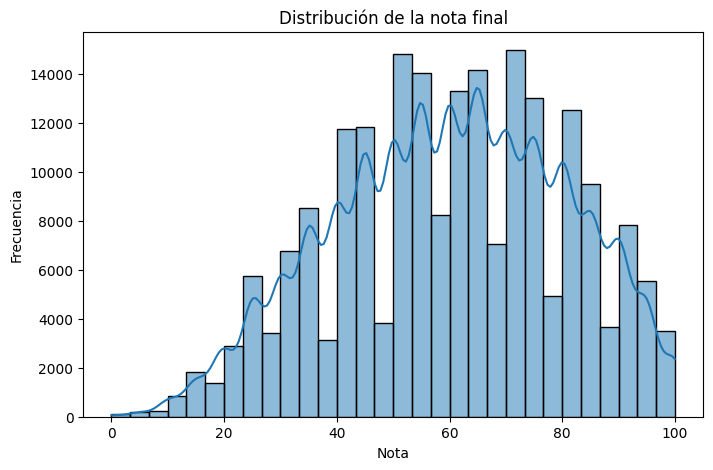

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["Nota en prueba"], bins=30, kde=True)

plt.title("Distribución de la nota final")
plt.xlabel("Nota")
plt.ylabel("Frecuencia")

plt.show()

El histograma de la nota final tiene una distribución con mayor concentración de valores entre 50 y 80 puntos. El pico principal de la distribución se ubica entre 60 y 70, lo cual coincide con el promedio calculado previamente.

La forma de la curva indica que la mayor parte de los estudiantes obtiene calificaciones medias, mientras que los valores extremos tienen menor frecuencia. Esto sugiere una variabilidad moderada en el desempeño académico, con estudiantes distribuidos en distintos niveles de rendimiento.

# 2. Distribución de aprobación
Se analiza la proporción de estudiantes que aprobaron o reprobaron la prueba. Este análisis es importante para entender si el conjunto de datos presenta un balance entre ambas clases, lo cual puede influir en el entrenamiento de modelos de clasificación.

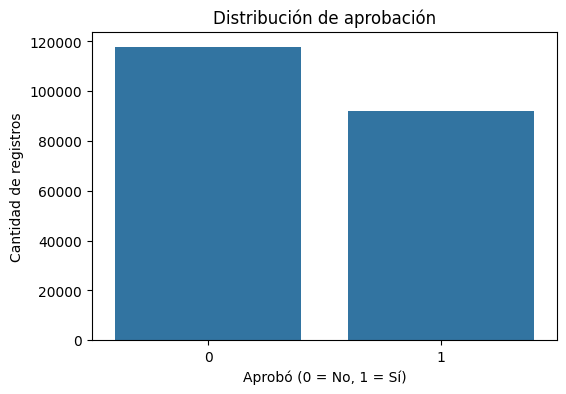

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x="Aprobó", data=df)

plt.title("Distribución de aprobación")
plt.xlabel("Aprobó (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de registros")

plt.show()

El gráfico de distribución de aprobación muestra la proporción de estudiantes que aprobaron (1) frente a aquellos que no aprobaron (0).

Se observa que la cantidad de estudiantes que no aprueban es mayor que la de quienes aprueban. Sin embargo, la diferencia entre ambas categorías no es tan alta, lo que indica que el conjunto de datos presenta una distribución balanceada entre aprobados y reprobados.

# 3. Comparación del desempeño promedio por grado
En esta sección se analiza el promedio de las notas de los estudiantes según el grado académico. Esto permite identificar posibles diferencias en el rendimiento entre los distintos niveles educativos.

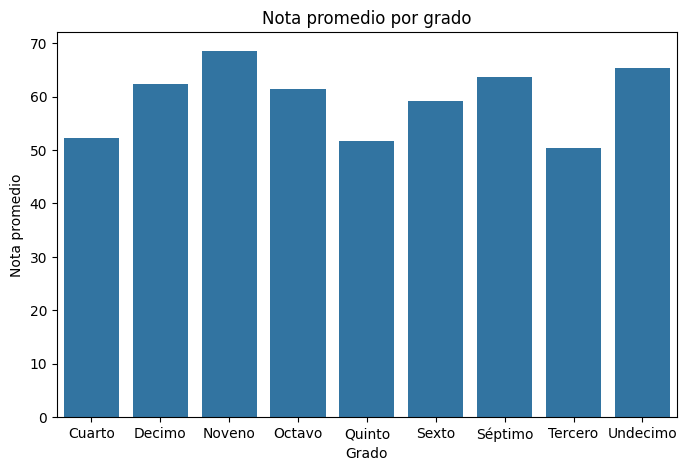

In [14]:
nota_grado = df.groupby("Grado")["Nota en prueba"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(data=nota_grado, x="Grado", y="Nota en prueba")

plt.title("Nota promedio por grado")
plt.xlabel("Grado")
plt.ylabel("Nota promedio")

plt.show()

El análisis del desempeño promedio por grado revela diferencias entre los niveles educativos. Algunos grados presentan promedios cercanos o superiores a 65–70 puntos, mientras que otros se sitúan alrededor de 50–55 puntos.

En grados como Noveno y Undécimo presentan promedios relativamente más altos, lo que podría indicar un mayor nivel de preparación académica o mayor familiaridad con el tipo de evaluación aplicada. Por otro lado, grados como Tercero y Quinto muestran promedios más bajos, lo cual puede deberse a la dificultad relativa del contenido evaluado o al nivel de desarrollo académico esperado en esos niveles.

# 4. Comparación del desempeño promedio por prueba
En esta sección se analiza el promedio de las notas según el tipo de prueba aplicada. Esto permite identificar evaluaciones que presentan mayor o menor dificultad para los estudiantes.

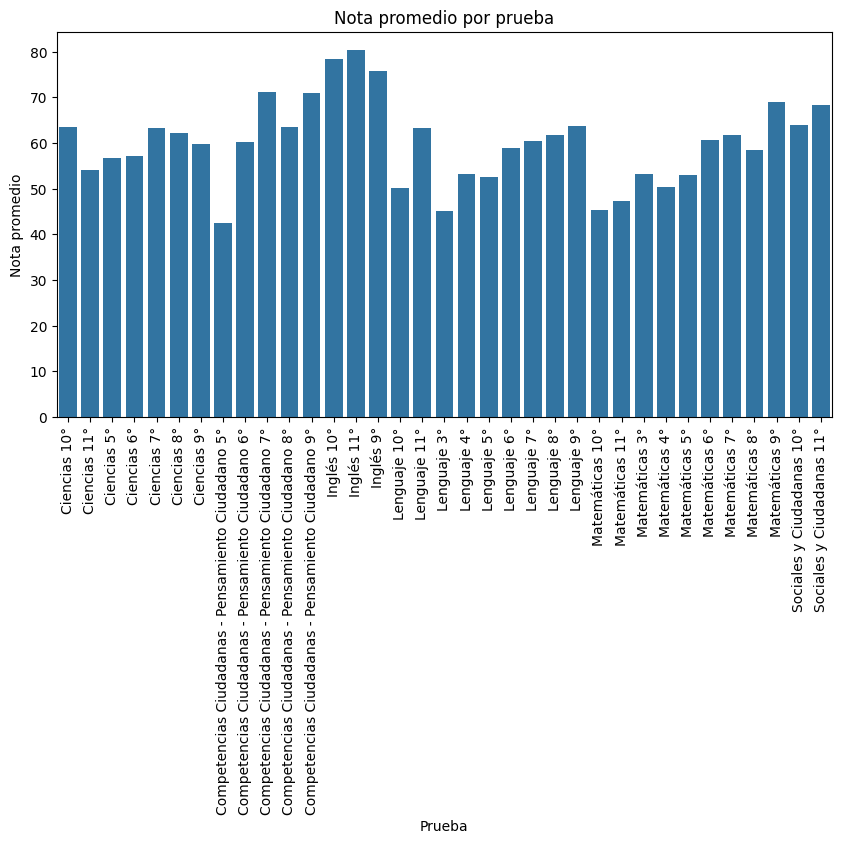

In [15]:
nota_prueba = df.groupby("Prueba")["Nota en prueba"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(data=nota_prueba, x="Prueba", y="Nota en prueba")

plt.xticks(rotation=90)

plt.title("Nota promedio por prueba")
plt.xlabel("Prueba")
plt.ylabel("Nota promedio")

plt.show()

El gráfico de desempeño promedio por prueba permite comparar el rendimiento de los estudiantes en diferentes áreas o evaluaciones. Se observa que algunas pruebas presentan promedios considerablemente más altos que otras.

Por ejemplo, evaluaciones relacionadas con Inglés tienen promedios cercanos a 75–80 puntos, lo que muestra que los estudiantes tienden a obtener mejores resultados en estas pruebas. En contraste, algunas pruebas asociadas con Lenguaje o Pensamiento Ciudadano muestran promedios más bajos, cercanos a 40–50 puntos, lo que podría indicar mayor dificultad o mayor exigencia en esas evaluaciones.

# 5. Diferencias entre grupos relevantes
Se analiza el desempeño de los estudiantes considerando variables demográficas relevantes, como el género. Esto permite explorar posibles diferencias en los resultados académicos entre distintos grupos de estudiantes.

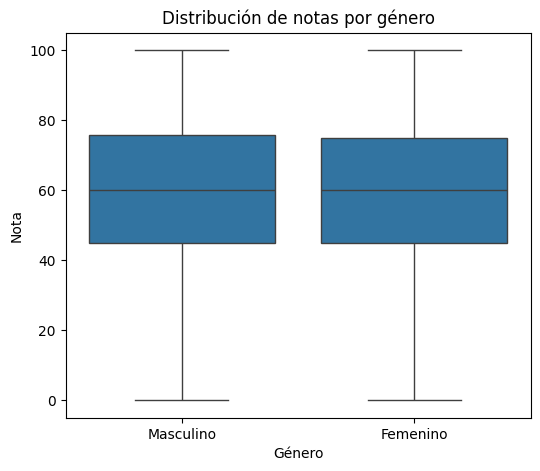

In [18]:

plt.figure(figsize=(6,5))

sns.boxplot(x="Genero", y="Nota en prueba", data=df)

plt.title("Distribución de notas por género")
plt.xlabel("Género")
plt.ylabel("Nota")

plt.show()

La distribución de notas por género permite comparar la distribución de calificaciones entre estudiantes masculinos y femeninos.

En el gráfico se observa que ambos grupos presentan medianas muy similares, cercanas a 60 puntos, y rangos de dispersión comparables. Además, los valores máximos y mínimos son prácticamente iguales en ambos grupos.

Esto sugiere que no existen diferencias en el desempeño académico entre géneros dentro de este conjunto de datos. La distribución de las calificaciones parece ser bastante homogénea entre ambos grupos.

# 6. Formulación de hipótesis
A partir de los patrones observados en el análisis exploratorio, se pueden plantear algunas hipótesis que podrían explorarse en análisis posteriores:

El desempeño académico de los estudiantes puede variar según el grado escolar.
Algunas pruebas presentan mayor nivel de dificultad que otras, lo cual se refleja en promedios de nota más bajos.
Podrían existir diferencias en el rendimiento entre distintos grupos de estudiantes.
La distribución de las notas sugiere que la mayoría de los estudiantes se concentra en niveles de desempeño intermedio.
Estas hipótesis podrían evaluarse posteriormente mediante modelos de análisis predictivo o técnicas de interpretabilidad como LIME o SHAP.

## Interpretación del análisis exploratorio
### Tarea
Redactar una síntesis de los hallazgos del análisis exploratorio.

### La síntesis debe responder al menos:
1. ¿Qué patrón general se observa en las notas?
2. ¿Qué patrón general se observa en la aprobación?
3. ¿Qué grupos parecen rendir mejor o peor?
4. ¿Qué hallazgos podrían ser relevantes para el modelado?
### Producto esperado
Un texto interpretativo, no solo tablas ni gráficos.

El análisis exploratorio de los datos permitió identificar varios patrones relevantes en el desempeño académico de los estudiantes. Primero, al analizar la distribución de las notas finales se observa que la mayoría de los estudiantes obtiene calificaciones en un rango intermedio, principalmente entre 50 y 80 puntos, con un promedio cercano a 60 puntos. La distribución presenta una dispersión moderada a lo largo del rango de calificaciones, lo cual indica que existen estudiantes con desempeños diferentes, desde resultados muy bajos hasta resultados altos. Sin embargo, la mayor concentración de estudiantes se encuentra en niveles de desempeño medio.

En relación con la aprobación, el análisis muestra que la cantidad de estudiantes que aprueban y los que no aprueban es relativamente similar, aunque se observa una ligera mayor proporción de estudiantes que no aprueban. Esto indica que la variable de aprobación se encuentra balanceada, lo cual resulta positivo para posteriores tareas de modelado, especialmente si se utilizan modelos de clasificación para predecir la probabilidad de aprobación.

Al comparar el desempeño promedio entre distintos grados, se observan diferencias claras entre niveles educativos. Algunos grados presentan promedios más altos, cercanos a 65–70 puntos, mientras que otros muestran promedios alrededor de 50–55 puntos. Esto sugiere que el rendimiento académico puede variar dependiendo del nivel educativo, posiblemente debido a la dificultad de los contenidos evaluados o a diferencias en el desarrollo académico de los estudiantes. En cambio, al analizar la distribución de notas por género, no se observan diferencias entre estudiantes masculinos y femeninos, ya que ambos grupos presentan distribuciones de notas muy similares.

Por otro lado, el análisis del desempeño promedio por tipo de prueba muestra variaciones importantes entre distintas evaluaciones. Algunas pruebas presentan promedios relativamente altos, lo que podría indicar que son más accesibles para los estudiantes, mientras que otras muestran promedios más bajos, lo cual sugiere mayor nivel de dificultad o mayor exigencia conceptual. Este tipo de análisis permite identificar áreas en las que los estudiantes presentan mayores dificultades y podría ser útil para orientar estrategias pedagógicas.

Por ultimo, estos hallazgos resultan relevantes para el modelado predictivo que se realizará posteriormente. La presencia de diferencias entre grados y entre tipos de prueba sugiere que variables como el grado académico, la prueba aplicada y otras características del contexto educativo podrían ser factores importantes para predecir el desempeño o la probabilidad de aprobación. Además, el hecho de que la variable de aprobación esté relativamente balanceada facilita el entrenamiento de modelos de clasificación sin requerir técnicas adicionales para manejar desbalances extremos.

# Parte 3. Diseño de modelos predictivos

## Objetivo

Construir dos enfoques diferentes y compararlos críticamente.

---

## Tareas

1. Definir qué variables entran en el modelo base.
2. Definir qué variables adicionales entran en el modelo de alerta temprana.
3. Justificar cada decisión.
4. Explicar por qué algunas variables quedan excluidas.

### Preguntas orientadoras

- ¿Qué significa predecir “antes” frente a predecir “durante” la prueba?
- ¿Qué variables son razonables en cada escenario?

### Producto esperado

Un diseño metodológico explícito para ambos modelos.

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [20]:
# 1. variables en el modelo base


target = "Aprobó"

base_features = [
    "Prueba",
    "Acierto",
    "Pregunta",
    "Respuesta"
]


X_base = df[base_features]
y = df[target]

In [25]:
categorical_cols = X_base.select_dtypes(include="object").columns.tolist()
numeric_cols = X_base.select_dtypes(include=["int64","float64"]).columns.tolist()


preprocessor_base = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

model_base = Pipeline(
    steps=[
        ("preprocess", preprocessor_base),
        ("model", RandomForestClassifier(n_estimators=200))
    ]
)

model_base.fit(X_train_base, y_train_base)
y_pred_base = model_base.predict(X_test_base)
print(classification_report(y_test_base, y_pred_base))

C:\Users\SEBASTIAN\AppData\Local\Temp\ipykernel_40932\3843856224.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_base.select_dtypes(include="object").columns.tolist()


              precision    recall  f1-score   support

           0       0.74      0.73      0.74     23626
           1       0.66      0.67      0.67     18337

    accuracy                           0.71     41963
   macro avg       0.70      0.70      0.70     41963
weighted avg       0.71      0.71      0.71     41963



In [26]:
accuracy_base = accuracy_score(y_test_base, y_pred_base)
print("Accuracy:", accuracy_base)

Accuracy: 0.7061697209446417


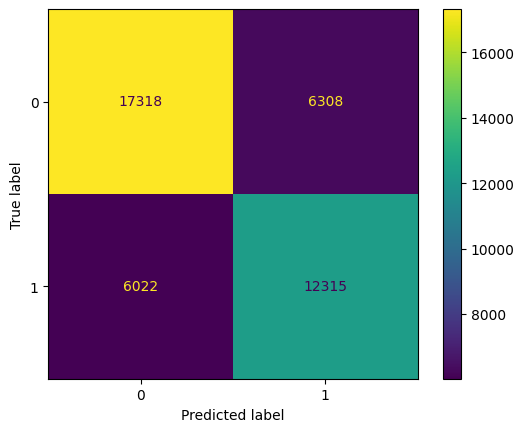

In [27]:
confusion_matrix(y_test_base, y_pred_base)
ConfusionMatrixDisplay.from_predictions(y_test_base, y_pred_base)

In [28]:
y_prob = model_base.predict_proba(X_test_base)

In [29]:
# 2 Variables de modelo alerta temprana
early_features = [
    "Sede",
    "Edad Estudiante",
    "Genero",
    "Grado",
    "Curso",
    "Antiguedad"
]

X_early = df[early_features]
y = df[target]

In [30]:
#Variables excluidas
excluded_features = [
    "Nota en prueba",
    "Aprobó"
]

## Justificación de elección de variables

las variables del modelo base, permite predecir un posible resultado a partir de datos obtenidos durante la prueba, por eso la selección son valores clasificables como, la pregunta, la respuesta, si acerto y que tipo de prueba es. Por el otro lado, las variables del modelo de alerta temprana, son valores que podrias presentar una relación descriptiva del estudiante, variables como: sede, curso, edad, genero, grado y antigüedad, este modelo suele generar sesgos de clasificación porque generaliza los valores que solo describen al estudiante si tener presente variables más arbitrarias que cuantifican los resultados. 

4. Se excluyen variables que puedan responder a 3 criterios: disponibilidad temporal, riesgo de fuga de información, y redundacia informativa. Su exclusión en parte se atribuye a razones metodológicas y estadísticas que pueden generar un direccionamiento a los datos que no permitan predicir sino recordar la información. 

In [31]:
categorical_cols = X_early.select_dtypes(include="object").columns.tolist()
numeric_cols = X_early.select_dtypes(include=["int64","float64"]).columns.tolist()

preprocessor_early = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

X_train_early, X_test_early, y_train_early, y_test_early = train_test_split(
    X_early, y, test_size=0.2, random_state=42
)

model_early = Pipeline(
    steps=[
        ("preprocess", preprocessor_early),
        ("model", RandomForestClassifier(n_estimators=200))
    ]
)

model_early.fit(X_train_early, y_train_early)
y_pred_early = model_early.predict(X_test_early)
print(classification_report(y_test_early, y_pred_early))

C:\Users\SEBASTIAN\AppData\Local\Temp\ipykernel_40932\3611498834.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_early.select_dtypes(include="object").columns.tolist()


              precision    recall  f1-score   support

           0       0.74      0.78      0.76     23626
           1       0.69      0.64      0.67     18337

    accuracy                           0.72     41963
   macro avg       0.71      0.71      0.71     41963
weighted avg       0.72      0.72      0.72     41963



In [32]:
accuracy_early = accuracy_score(y_test_early, y_pred_early)
print("Accuracy:", accuracy_early)

Accuracy: 0.7191811834234921


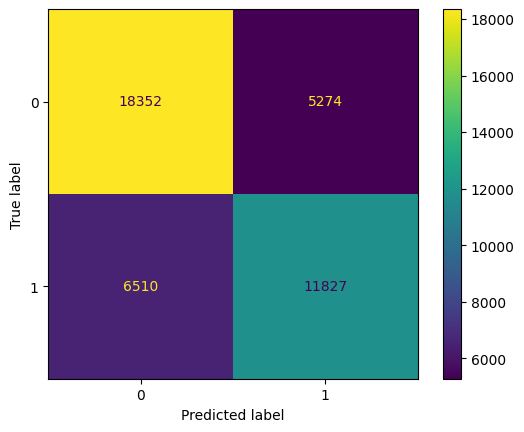

In [33]:
confusion_matrix(y_test_early, y_pred_early)
ConfusionMatrixDisplay.from_predictions(y_test_early, y_pred_early)

In [34]:
y_prob = model_early.predict_proba(X_test_early)

# Parte 4. Modelo de clasificación

## Objetivo

Predecir si un estudiante aprueba o no aprueba el test o una pregunta.

---

## Tareas

1. Definir la variable objetivo de clasificación.
2. Preparar el conjunto de datos para clasificación.
3. Separar entrenamiento y prueba.
4. Justificar la forma de partición usada.
5. Entrenar un modelo base.
6. Entrenar un modelo de alerta temprana.
7. Comparar el rendimiento de ambos.

### Métricas sugeridas

- accuracy
- precision
- recall
- F1
- matriz de confusión

### Preguntas orientadoras

- ¿Qué modelo clasifica mejor?
- ¿Qué errores comete cada uno?
- ¿El mejor desempeño implica mejor diseño metodológico?

### Producto esperado

Comparación entre ambos modelos y una interpretación crítica de sus resultados.

## Análisis de resultados de la Parte 3 y 4

A partir de las métricas de evaluación y las matrices de confución, se observa que ambos modelos presentan un rendimiento relativamente similar, aunque el modelo de alerta temprana muestra un desempeño ligeramente superior. Ambos modelos muestra valores cercanos a 0.70, por lo que es una buena predicción pero debe exisitir varias problemáticas entre las variables seleccionadas para responder a esto, existiendo posibles sesgos dada la naturaleza de los modelos y las variables seleccionadas para determinar si aprobó o no. 

Al analizar los errores de clasificación, se identifican diferencias en el comportamiento de cada modelo. El modelo base presenta valores de precisión y recall relativamente equilibrados para ambas clases, aunque su capacidad para identificar correctamente a los estudiantes que aprueban es menor que para aquellos que no aprueban. Esto implica que el modelo tiende a cometer errores tanto de falsos positivos como de falsos negativos, especialmente al predecir la aprobación. Por su parte, el modelo de alerta temprana mejora la detección de estudiantes que no aprueban, evidenciado por un mayor recall en la clase correspondiente. Sin embargo, esta mejora se acompaña de una ligera reducción en la capacidad para identificar correctamente a los estudiantes que sí aprueban, lo que implica un incremento en los falsos negativos para esta clase.

El modelo base utiliza variables generadas durante la realización de la prueba, como respuestas o aciertos, lo cual introduce información directa sobre el desempeño del estudiante y puede facilitar la predicción del resultado final. En contraste, el modelo de alerta temprana se construye únicamente con variables disponibles antes de que el estudiante presente la prueba. Aunque este enfoque puede tener una capacidad predictiva ligeramente menor o similar, resulta metodológicamente más relevante en contextos educativos, ya que permite identificar estudiantes en riesgo con anticipación y potencialmente implementar intervenciones preventivas antes de la evaluación.

## Interpretación del modelo de clasificación

### Tarea

Redactar una interpretación de los resultados del modelo de clasificación.

### La interpretación debe incluir

1. Qué tan bien clasifica el modelo base.
2. Qué tan bien clasifica el modelo de alerta temprana.
3. Qué diferencias aparecen entre ambos.
4. Qué conclusiones metodológicas se desprenden.

### Producto esperado

Un texto comparativo con mirada crítica.

# Parte 5. Modelo de regresión

## Objetivo

Predecir la nota final obtenida en la prueba.

---

## Tareas

1. Definir la variable objetivo de regresión.
2. Preparar el conjunto de datos para regresión.
3. Entrenar un modelo base.
4. Entrenar un modelo de alerta temprana.
5. Comparar ambos modelos.

### Métricas sugeridas

- MAE
- RMSE
- R²

### Preguntas orientadoras

- ¿Qué modelo predice mejor la nota?
- ¿Cuánto mejora al incorporar información temprana?
- ¿Es una mejora pequeña, moderada o grande?

### Producto esperado

Una comparación razonada entre ambos enfoques de regresión.

In [35]:
# Parte 5. Modelo de regresión
# Se trabaja a nivel estudiante-prueba para evitar repetir la misma nota final
# en múltiples filas de preguntas, lo que inflaría artificialmente el tamaño muestral.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [36]:

# -------------------------------------------------------------------
# 1) Preparación rigurosa de la base para regresión
# -------------------------------------------------------------------

df_reg = df.copy()

# Asegurar tipo numérico de la variable objetivo
df_reg["Nota en prueba"] = (
    df_reg["Nota en prueba"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
)
df_reg["Nota en prueba"] = pd.to_numeric(df_reg["Nota en prueba"], errors="coerce")

# Orden interno dentro de cada estudiante-prueba para construir variables tempranas
df_reg = df_reg.sort_values(["ID Estudiante", "Prueba", "QuestionId"]).reset_index(drop=True)
df_reg["orden_pregunta"] = df_reg.groupby(["ID Estudiante", "Prueba"]).cumcount() + 1
df_reg["total_preguntas_prueba"] = df_reg.groupby(["ID Estudiante", "Prueba"])["QuestionId"].transform("size")

# Se define una ventana temprana = primeras 20% de preguntas (mínimo 3)
df_reg["umbral_temprano"] = np.ceil(df_reg["total_preguntas_prueba"] * 0.20).clip(lower=3)
df_reg["es_temprano"] = df_reg["orden_pregunta"] <= df_reg["umbral_temprano"]

# Base única por estudiante-prueba
base_reg = (
    df_reg.groupby(["ID Estudiante", "Prueba"], as_index=False)
    .agg({
        "Sede": "first",
        "Edad Estudiante": "first",
        "Genero": "first",
        "Grado": "first",
        "Curso": "first",
        "Antiguedad": "first",
        "Nota en prueba": "first",
        "Aprobó": "first",
        "total_preguntas_prueba": "first"
    })
)

# Variables de alerta temprana construidas SOLO con el comienzo de la prueba
temprano = (
    df_reg[df_reg["es_temprano"]]
    .groupby(["ID Estudiante", "Prueba"], as_index=False)
    .agg(
        preguntas_tempranas=("QuestionId", "count"),
        aciertos_tempranos=("Acierto", "sum"),
        tasa_acierto_temprana=("Acierto", "mean"),
        competencias_tempranas=("Competencia", "nunique"),
        respuestas_tempranas_no_nulas=("Respuesta", lambda x: x.notna().sum())
    )
)

reg_data = base_reg.merge(temprano, on=["ID Estudiante", "Prueba"], how="left")

# Revisión global de la base final de modelado
print("Observaciones estudiante-prueba:", len(reg_data))
print("Estudiantes únicos:", reg_data["ID Estudiante"].nunique())
print("Pruebas únicas:", reg_data["Prueba"].nunique())
print("Promedio de preguntas por estudiante-prueba:", round(reg_data["total_preguntas_prueba"].mean(), 2))
print("Mediana de preguntas por estudiante-prueba:", round(reg_data["total_preguntas_prueba"].median(), 2))
print("Nota promedio:", round(reg_data["Nota en prueba"].mean(), 2))
print("Desviación estándar de la nota:", round(reg_data["Nota en prueba"].std(), 2))
print("Mínimo / máximo nota:", reg_data["Nota en prueba"].min(), "/", reg_data["Nota en prueba"].max())

Observaciones estudiante-prueba: 8356
Estudiantes únicos: 2393
Pruebas únicas: 35
Promedio de preguntas por estudiante-prueba: 25.11
Mediana de preguntas por estudiante-prueba: 20.0
Nota promedio: 59.27
Desviación estándar de la nota: 20.54
Mínimo / máximo nota: 0.0 / 100.0


In [37]:


# -------------------------------------------------------------------
# 2) Definición de variable objetivo y conjuntos de variables
# -------------------------------------------------------------------

target_reg = "Nota en prueba"

# Modelo base: información disponible sin usar desempeño dentro de la prueba
base_features_reg = [
    "Sede",
    "Edad Estudiante",
    "Genero",
    "Grado",
    "Curso",
    "Antiguedad",
    "Prueba"
]

# Modelo de alerta temprana: añade señales del comienzo de la prueba
early_features_reg = base_features_reg + [
    "preguntas_tempranas",
    "aciertos_tempranos",
    "tasa_acierto_temprana",
    "competencias_tempranas",
    "respuestas_tempranas_no_nulas"
]

X_base_reg = reg_data[base_features_reg].copy()
X_early_reg = reg_data[early_features_reg].copy()
y_reg = reg_data[target_reg].copy()

# Misma partición para ambos modelos, para compararlos de forma justa
idx = reg_data.index
idx_train, idx_test = train_test_split(idx, test_size=0.20, random_state=42)

X_train_base_reg = X_base_reg.loc[idx_train]
X_test_base_reg = X_base_reg.loc[idx_test]
X_train_early_reg = X_early_reg.loc[idx_train]
X_test_early_reg = X_early_reg.loc[idx_test]
y_train_reg = y_reg.loc[idx_train]
y_test_reg = y_reg.loc[idx_test]



In [38]:
# -------------------------------------------------------------------
# 3) Preprocesamiento
# -------------------------------------------------------------------

def construir_preprocesador(X):
    cat_cols = X.select_dtypes(include="object").columns.tolist()
    num_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("num", "passthrough", num_cols)
        ]
    )

preprocessor_base_reg = construir_preprocesador(X_train_base_reg)
preprocessor_early_reg = construir_preprocesador(X_train_early_reg)



C:\Users\SEBASTIAN\AppData\Local\Temp\ipykernel_40932\4288243737.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()
C:\Users\SEBASTIAN\AppData\Local\Temp\ipykernel_40932\4288243737.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/d

In [39]:
# -------------------------------------------------------------------
# 4) Entrenamiento de modelos
# -------------------------------------------------------------------

# Se usa el mismo algoritmo en ambos modelos para que la comparación sea limpia
model_base_reg = Pipeline(
    steps=[
        ("preprocess", preprocessor_base_reg),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

model_early_reg = Pipeline(
    steps=[
        ("preprocess", preprocessor_early_reg),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

model_base_reg.fit(X_train_base_reg, y_train_reg)
model_early_reg.fit(X_train_early_reg, y_train_reg)

pred_base_reg = model_base_reg.predict(X_test_base_reg)
pred_early_reg = model_early_reg.predict(X_test_early_reg)



In [40]:
# -------------------------------------------------------------------
# 5) Evaluación
# -------------------------------------------------------------------

def metricas_regresion(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

metrics_base_reg = metricas_regresion(y_test_reg, pred_base_reg)
metrics_early_reg = metricas_regresion(y_test_reg, pred_early_reg)

resultados_reg = pd.DataFrame([
    {"Modelo": "Base", **metrics_base_reg},
    {"Modelo": "Alerta temprana", **metrics_early_reg}
])

print("\nComparación de modelos de regresión")
display(resultados_reg.round(4))

mejora_mae = (metrics_base_reg["MAE"] - metrics_early_reg["MAE"]) / metrics_base_reg["MAE"] * 100
mejora_rmse = (metrics_base_reg["RMSE"] - metrics_early_reg["RMSE"]) / metrics_base_reg["RMSE"] * 100
delta_r2 = metrics_early_reg["R2"] - metrics_base_reg["R2"]

print(f"Mejora relativa en MAE del modelo temprano vs base: {mejora_mae:.2f}%")
print(f"Mejora relativa en RMSE del modelo temprano vs base: {mejora_rmse:.2f}%")
print(f"Cambio absoluto en R²: {delta_r2:.4f}")




Comparación de modelos de regresión


,Modelo,MAE,RMSE,R2
0,Base,14.9996,18.6641,0.1443
1,Alerta temprana,10.9469,13.7182,0.5377


Mejora relativa en MAE del modelo temprano vs base: 27.02%
Mejora relativa en RMSE del modelo temprano vs base: 26.50%
Cambio absoluto en R²: 0.3934


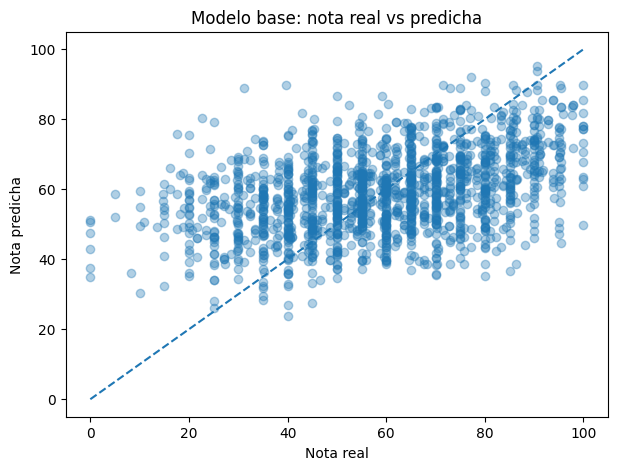

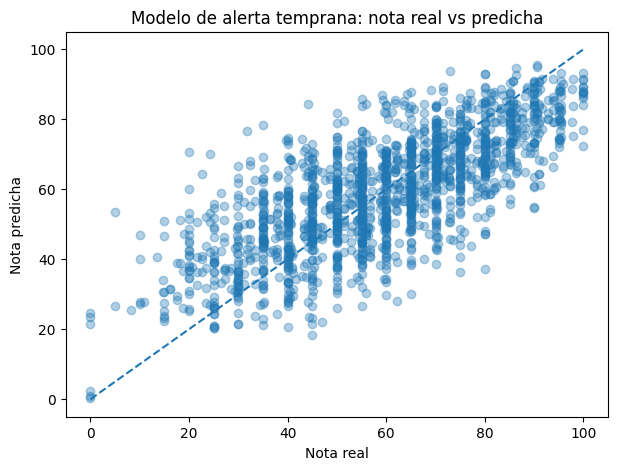

In [41]:
# -------------------------------------------------------------------
# 6) Visualización comparativa
# -------------------------------------------------------------------

comparacion_pred = pd.DataFrame({
    "real": y_test_reg.values,
    "pred_base": pred_base_reg,
    "pred_temprano": pred_early_reg
})

lim_inf = min(comparacion_pred[["real", "pred_base", "pred_temprano"]].min())
lim_sup = max(comparacion_pred[["real", "pred_base", "pred_temprano"]].max())

plt.figure(figsize=(7, 5))
plt.scatter(comparacion_pred["real"], comparacion_pred["pred_base"], alpha=0.35)
plt.plot([lim_inf, lim_sup], [lim_inf, lim_sup], linestyle="--")
plt.title("Modelo base: nota real vs predicha")
plt.xlabel("Nota real")
plt.ylabel("Nota predicha")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(comparacion_pred["real"], comparacion_pred["pred_temprano"], alpha=0.35)
plt.plot([lim_inf, lim_sup], [lim_inf, lim_sup], linestyle="--")
plt.title("Modelo de alerta temprana: nota real vs predicha")
plt.xlabel("Nota real")
plt.ylabel("Nota predicha")
plt.show()



In [42]:
# -------------------------------------------------------------------
# 7) Resumen estadístico del error
# -------------------------------------------------------------------

errores_reg = pd.DataFrame({
    "error_base": y_test_reg.values - pred_base_reg,
    "error_temprano": y_test_reg.values - pred_early_reg
})

display(errores_reg.describe().round(3))

,error_base,error_temprano
count,1672.000,1672.000
mean,-0.202,-0.340
std,18.669,13.718
min,-58.187,-50.617
25%,-12.957,-9.123
50%,0.661,0.106
75%,13.190,9.308
max,50.928,42.853


Se desarrolló un modelo de regresión con el objetivo de predecir la nota final en la prueba. Para que el análisis fuera metodológicamente correcto, la unidad de observación se definió a nivel estudiante-prueba y no a nivel de pregunta individual. Esta decisión fue importante porque la nota final es una variable que se repite en múltiples filas dentro de una misma prueba; por lo tanto, si se hubiera modelado directamente a nivel de pregunta, se habría inflado artificialmente el tamaño muestral y se habría sobrestimado la capacidad predictiva del modelo.

Primero se estimó un modelo base, construido únicamente con variables estructurales disponibles antes o al inicio de la evaluación, como sede, edad, género, grado, curso, antigüedad y tipo de prueba. Este modelo alcanzó un MAE de 15.000, un RMSE de 18.664 y un R² de 0.144. En términos prácticos, estos resultados muestran que el modelo logra capturar una parte del comportamiento de la nota, aunque todavía presenta un margen de error relevante, algo esperable en fenómenos educativos donde intervienen múltiples factores no observados.

Posteriormente se construyó un modelo de alerta temprana, al que se le añadieron señales del primer tramo del examen, como el número de preguntas tempranas respondidas, los aciertos iniciales, la tasa de acierto temprana, el número de competencias cubiertas y la cantidad de respuestas no nulas en esa fase inicial. Este segundo modelo obtuvo un MAE de 10.947, un RMSE de 13.718 y un R² de 0.538.

Al comparar ambos enfoques, se observa que el modelo de alerta temprana supera al modelo base. En particular, la incorporación de señales tempranas produjo una mejora relativa de 27.02% en MAE, 26.50% en RMSE y un aumento absoluto de 0.393 puntos en R², lo que sugiere una mejora importante en capacidad predictiva. Desde una perspectiva estadística y aplicada, este resultado es coherente: el comportamiento del estudiante al inicio de la prueba aporta información valiosa sobre su desempeño final, aun cuando todavía no se ha observado el examen completo.

En términos sustantivos, el hallazgo más importante es que un sistema de este tipo podría utilizarse como herramienta de monitoreo o intervención temprana. Si un modelo detecta, desde los primeros ítems, que un estudiante probablemente tendrá un bajo desempeño final, la institución podría activar apoyos pedagógicos, seguimiento o alertas preventivas. Sin embargo, esta utilidad debe entenderse dentro de ciertos límites: el modelo no explica causalmente por qué un estudiante obtiene una determinada nota, sino que identifica patrones predictivos en los datos observados.

Además, aunque el modelo de alerta temprana mejora frente al modelo base, sus resultados no deben interpretarse como una predicción perfecta. El error residual indica que siguen existiendo factores no observados —como motivación, cansancio, contexto familiar, calidad de preparación previa o condiciones del momento del examen— que también afectan la nota y no están plenamente capturados en la base. Por ello, este tipo de modelos debe verse como una herramienta complementaria para apoyar decisiones, y no como un sustituto del juicio pedagógico o del análisis contextual.

En conclusión, la parte 5 muestra que sí es posible predecir razonablemente la nota final de una prueba usando información estructural y señales tempranas del examen, y que la inclusión de indicadores iniciales mejora el desempeño predictivo del modelo. Esto respalda la idea de que los modelos de regresión pueden tener un valor práctico en entornos educativos, especialmente cuando se busca identificar riesgo de bajo rendimiento de manera anticipada y actuar antes de que el resultado final ya esté consolidado.

## Interpretación del modelo de regresión

### Tarea

Redactar una interpretación de los resultados del modelo de regresión.

### La interpretación debe responder

1. ¿Qué tan preciso es el modelo base?
2. ¿Qué tan preciso es el modelo de alerta temprana?
3. ¿Qué implicaciones tiene esa diferencia?
4. ¿Qué utilidad real tendría este tipo de modelo?

### Producto esperado

Un texto interpretativo, no solo un reporte de métricas.

# Parte 6. Selección de un caso individual para interpretar

## Objetivo

Elegir una observación específica del conjunto de prueba para analizarla en detalle con herramientas de explicabilidad.

---

## Tareas

1. Seleccionar un caso individual.
2. Mostrar su valor real.
3. Mostrar la predicción del modelo.
4. Justificar por qué ese caso resulta interesante para interpretar.

### Preguntas orientadoras

- ¿Conviene elegir un caso típico o uno llamativo?
- ¿Conviene elegir un acierto del modelo o un error?

### Producto esperado

Un caso claramente identificado para el análisis con LIME y SHAP.

In [48]:
y_pred = model_early.predict(X_test_early)
errores = y_pred != y_test_early
num_cols = ["Edad Estudiante", "Antiguedad"]

median_vals = X_test_early[num_cols].median()

dist = ((X_test_early[num_cols] - median_vals)**2).sum(axis=1)
dist_errores = dist[errores]
idx_tipico_error = dist_errores.idxmin()
caso_estudio = X_test_early.loc[[idx_tipico_error]]

print(caso_estudio)

pred = model_early.predict(caso_estudio)[0]
prob = model_early.predict_proba(caso_estudio)[0]

real = y_test_early.loc[idx_tipico_error]

print("Valor real:", real)
print("Predicción modelo:", pred)
print("Probabilidad reprobar:", prob[0])
print("Probabilidad aprobar:", prob[1])

                          Sede  Edad Estudiante    Genero    Grado Curso  \
122260  Colegio Cundinamarca 2               13  Femenino  Séptimo   7.A   

        Antiguedad  
122260           1  
Valor real: 1
Predicción modelo: 0
Probabilidad reprobar: 0.550931186146402
Probabilidad aprobar: 0.449068813853598


Es más conveniente identificar un caso típico que el modelo haya fallado al predecir, para entender como está generalizando el modelo a nivel global e identificar los errores del modelo a nivel local, para encontrar un caso que permita realizar esto, se identifican los casos errados por el modelo, y se calcula la mediana para las variables numéricas, permitiendo encontrar el caso menos alejado de la mediana, es decir el más típico que fue errado. El valor real indica "Aprobó", mientras el modelo lo clasificó como "Reprobó".

# Parte 7. Interpretación con LIME

## Objetivo

Explicar localmente por qué el modelo realizó una predicción específica.

---

## Tareas

1. Aplicar LIME al caso seleccionado.
2. Revisar qué variables empujan la predicción en una dirección y cuáles en otra.
3. Describir la explicación con palabras.

### Preguntas orientadoras

- ¿Qué variables favorecen el resultado predicho?
- ¿Qué variables lo debilitan?
- ¿La explicación parece coherente con la lógica del problema?

### Producto esperado

Una interpretación escrita de la explicación local de LIME.

Caso analizado (index): 122260
Valor real: 1
Predicción del modelo: 0
Probabilidad clase predicha (0): 0.5509

Contribuciones locales de LIME (ordenadas por magnitud):


,factor,contribucion
0,Grado=Séptimo,-0.064113
1,Curso=7.A,-0.047675
2,Genero=Femenino,0.043946
3,11.00 < Edad Estudiante <= 13.00,-0.023138
4,0.00 < Antiguedad <= 1.00,0.019790
5,Sede=Colegio Cundinamarca 2,-0.001295


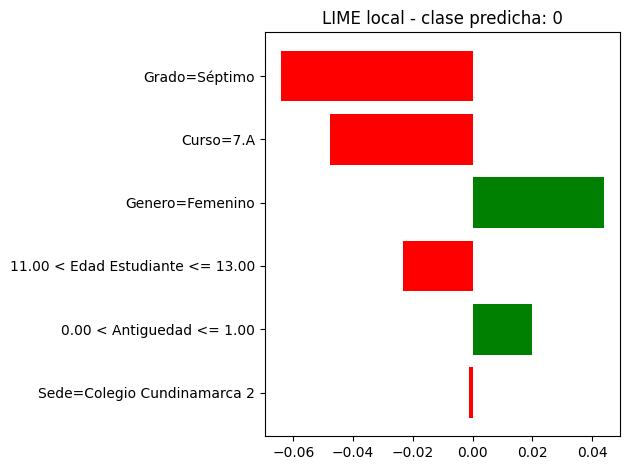

In [47]:
# Parte 7. Interpretación con LIME (explicación local)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer

# Usamos una copia de entrenamiento y codificamos solo para LIME
X_train_ref = X_train_early.copy()
feature_names = X_train_ref.columns.tolist()

categorical_cols = X_train_ref.select_dtypes(
    include=["object", "category", "bool", "string"]
).columns.tolist()
numeric_cols_lime = [c for c in feature_names if c not in categorical_cols]

categorical_features = [feature_names.index(c) for c in categorical_cols]

# Mapa categoría <-> código por columna categórica
category_maps = {}
for col in categorical_cols:
    vals = X_train_ref[col].astype(str).fillna("MISSING")
    category_maps[col] = sorted(vals.unique().tolist())

categorical_names = {
    feature_names.index(col): category_maps[col]
    for col in categorical_cols
}

# Medianas para imputar faltantes en variables numéricas
numeric_medians = {}
for col in numeric_cols_lime:
    s = pd.to_numeric(X_train_ref[col], errors="coerce")
    med = s.median()
    numeric_medians[col] = float(med) if pd.notna(med) else 0.0

def encode_for_lime(df):
    out = df.copy()
    for col in categorical_cols:
        mapping = {v: i for i, v in enumerate(category_maps[col])}
        out[col] = (
            out[col].astype(str).fillna("MISSING").map(mapping).fillna(0).astype(int)
        )
    for col in numeric_cols_lime:
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(numeric_medians[col])
    return out[feature_names]

def decode_for_model(df_encoded):
    out = df_encoded.copy()
    for col in categorical_cols:
        cats = category_maps[col]
        codes = pd.to_numeric(out[col], errors="coerce").fillna(0)
        codes = np.rint(codes).astype(int)
        codes = np.clip(codes, 0, max(len(cats) - 1, 0))
        out[col] = pd.Series(codes, index=out.index).map(lambda i: cats[i])
    for col in numeric_cols_lime:
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(numeric_medians[col])
    return out[feature_names]

X_train_lime = encode_for_lime(X_train_ref)

class_names = [str(c) for c in model_early.classes_]

explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=feature_names,
    class_names=class_names,
    categorical_features=categorical_features,
    categorical_names=categorical_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

def predict_fn(x_array):
    x_df_encoded = pd.DataFrame(x_array, columns=feature_names)
    x_df_model = decode_for_model(x_df_encoded)
    return model_early.predict_proba(x_df_model)

# Caso definido en la Parte 6
x_case = caso_estudio.iloc[[0]][feature_names]
x_case_lime = encode_for_lime(x_case).iloc[0]

pred = model_early.predict(caso_estudio)[0]
proba = model_early.predict_proba(caso_estudio)[0]
pred_idx = int(np.where(model_early.classes_ == pred)[0][0])

lime_exp = explainer.explain_instance(
    data_row=x_case_lime.values,
    predict_fn=predict_fn,
    num_features=min(8, len(feature_names)),
    top_labels=1
)

lime_df = pd.DataFrame(
    lime_exp.as_list(label=pred_idx),
    columns=["factor", "contribucion"]
)

print(f"Caso analizado (index): {caso_estudio.index[0]}")
print(f"Valor real: {real}")
print(f"Predicción del modelo: {pred}")
print(f"Probabilidad clase predicha ({pred}): {proba[pred_idx]:.4f}")

print("\nContribuciones locales de LIME (ordenadas por magnitud):")
display(lime_df.reindex(lime_df.contribucion.abs().sort_values(ascending=False).index))

fig = lime_exp.as_pyplot_figure(label=pred_idx)
plt.title(f"LIME local - clase predicha: {pred}")
plt.tight_layout()
plt.show()

## Interpretación escrita de LIME

### Tarea

Redactar una explicación textual de la gráfica de LIME.

### La redacción debe incluir

1. Si la explicación es local o global.
2. Qué factores empujan más a favor del resultado.
3. Qué factores empujan más en contra.
4. Una síntesis narrativa del caso.

### Producto esperado

Un texto claro, interpretativo y bien argumentado.

 Para el estudiante de la Sede Colegio Cundinamarca 2, con 13 años, género femenino, grado séptimo, curso 7.A y antigüedad de 1 año, el modelo estimó una mayor probabilidad de reprobación.

Esta predicción estuvo influenciada principalmente por el hecho de estar en grado séptimo y en el curso 7.A, variables que el modelo asocia localmente con un mayor riesgo académico. Aunque características como ser mujer y tener baja antigüedad en la institución aportaron de forma positiva hacia la probabilidad de aprobar, su efecto fue menor frente al impacto negativo de las variables relacionadas con el nivel y grupo escolar.

Por esta razón, el modelo clasificó al estudiante como reprobado, aun cuando en la realidad el estudiante sí aprobó.

# Parte 8. Interpretación con SHAP local

## Objetivo

Explicar un caso individual usando contribuciones aditivas.

---

## Tareas

1. Aplicar SHAP local al caso seleccionado.
2. Identificar el valor base.
3. Identificar la suma de contribuciones.
4. Verificar cómo se reconstruye la predicción final.
5. Analizar qué variables tienen mayor contribución positiva y negativa.

### Preguntas orientadoras

- ¿Qué significa el valor base?
- ¿Qué significa que una contribución sea positiva o negativa?
- ¿Qué diferencia hay entre esta lógica y la de LIME?

### Producto esperado

Una interpretación escrita de la explicación local de SHAP.

c:\Users\SEBASTIAN\AppData\Local\pypoetry\Cache\virtualenvs\cxai-m-GbK5JxQ3-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Caso analizado (index): 122260
Valor real: 1
Clase predicha: 0
Probabilidad clase predicha: 0.550931
Valor base SHAP (clase 0): 0.492884
Suma de contribuciones SHAP: 0.058047
Reconstrucción base + contribuciones: 0.550931
Diferencia absoluta vs probabilidad del modelo: 0.00000000

Top contribuciones locales (SHAP):


,feature,shap_value
4,cat__Sede_Colegio Cundinamarca 2,0.062321
46,num__Edad Estudiante,-0.040939
5,cat__Sede_Colegio Cundinamarca 3,0.025416
14,cat__Grado_Séptimo,-0.024454
12,cat__Grado_Quinto,-0.016502
10,cat__Grado_Noveno,0.016220
1,cat__Sede_Colegio Boyacá 1,0.011799
44,cat__Curso_9.B,0.010860
7,cat__Genero_Masculino,0.010162
6,cat__Genero_Femenino,0.008357


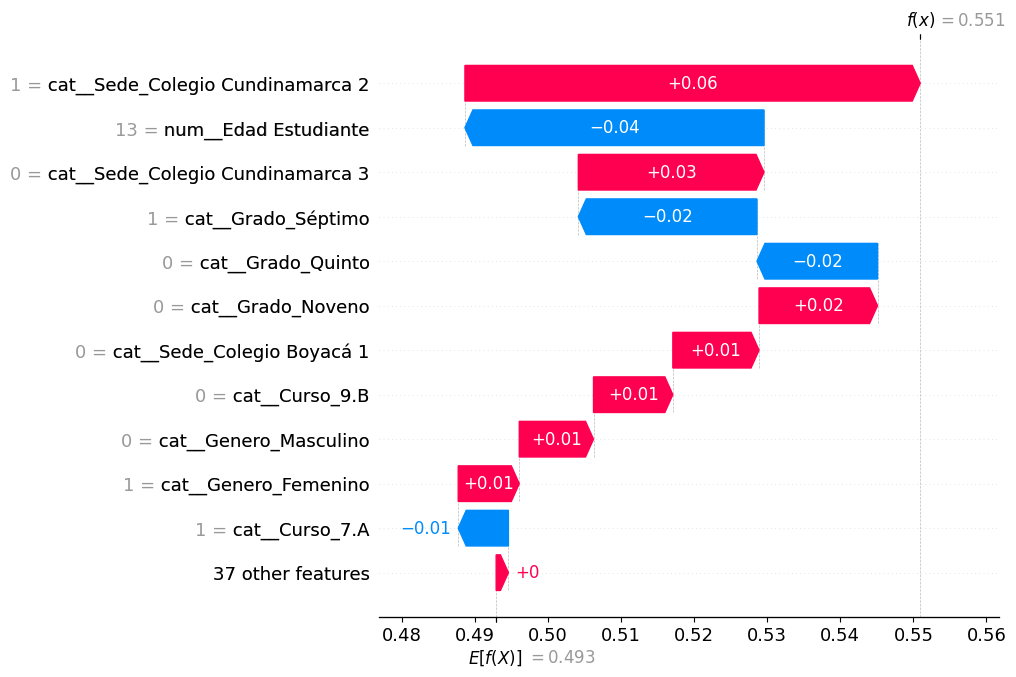

In [50]:
# Parte 8. SHAP local para el mismo caso individual
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 1) Transformar datos con el preprocesador del pipeline
X_train_trans = preprocessor_early.transform(X_train_early)
X_case_raw = caso_estudio[early_features].copy()
X_case_trans = preprocessor_early.transform(X_case_raw)

if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
if hasattr(X_case_trans, "toarray"):
    X_case_trans = X_case_trans.toarray()

feature_names_shap = preprocessor_early.get_feature_names_out()
rf_model = model_early.named_steps["model"]

# 2) Definir clase predicha para el caso
pred_shap = model_early.predict(X_case_raw)[0]
proba_shap = model_early.predict_proba(X_case_raw)[0]
pred_idx_shap = int(np.where(model_early.classes_ == pred_shap)[0][0])

# 3) Explicador SHAP (salida en probabilidad)
background_size = min(300, X_train_trans.shape[0])
background = X_train_trans[:background_size]

explainer_shap = shap.TreeExplainer(
    rf_model,
    data=background,
    model_output="probability"
)

shap_values_all = explainer_shap.shap_values(X_case_trans)
expected_values = explainer_shap.expected_value

# Compatibilidad con distintas salidas de SHAP
if isinstance(shap_values_all, list):
    shap_values_case = shap_values_all[pred_idx_shap][0]
else:
    shap_values_case = shap_values_all[0, :, pred_idx_shap]

if isinstance(expected_values, (list, np.ndarray)):
    base_value_shap = float(expected_values[pred_idx_shap])
else:
    base_value_shap = float(expected_values)

sum_contrib_shap = float(np.sum(shap_values_case))
recon_proba_shap = base_value_shap + sum_contrib_shap
pred_proba_shap = float(proba_shap[pred_idx_shap])

shap_df = pd.DataFrame({
    "feature": feature_names_shap,
    "shap_value": shap_values_case
}).sort_values("shap_value", key=np.abs, ascending=False)

print(f"Caso analizado (index): {caso_estudio.index[0]}")
print(f"Valor real: {real}")
print(f"Clase predicha: {pred_shap}")
print(f"Probabilidad clase predicha: {pred_proba_shap:.6f}")
print(f"Valor base SHAP (clase {pred_shap}): {base_value_shap:.6f}")
print(f"Suma de contribuciones SHAP: {sum_contrib_shap:.6f}")
print(f"Reconstrucción base + contribuciones: {recon_proba_shap:.6f}")
print(f"Diferencia absoluta vs probabilidad del modelo: {abs(recon_proba_shap - pred_proba_shap):.8f}")

print("\nTop contribuciones locales (SHAP):")
display(shap_df.head(12))

exp_local = shap.Explanation(
    values=shap_values_case,
    base_values=base_value_shap,
    data=X_case_trans[0],
    feature_names=feature_names_shap
)

shap.plots.waterfall(exp_local, max_display=12)
plt.show()

## Interpretación escrita de SHAP local

### Tarea

Redactar una explicación textual de la gráfica local de SHAP.

### La redacción debe incluir

1. El significado del valor base.
2. El papel de las contribuciones individuales.
3. Qué variables suben o bajan la predicción.
4. Una síntesis narrativa del caso.

### Producto esperado

Un texto claro y técnicamente correcto.

El valor base del modelo (≈ 0.493) representa la probabilidad promedio de reprobar en la población, es decir, el riesgo esperado antes de considerar las características específicas del estudiante. A partir de este punto inicial, las contribuciones individuales de las variables ajustan la predicción hacia arriba o hacia abajo hasta alcanzar la probabilidad final estimada para este caso (≈ 0.551).

En particular, la variable que más incrementó la probabilidad de reprobar fue la pertenencia a la Sede Colegio Cundinamarca 2, seguida por efectos positivos asociados a no pertenecer a ciertas sedes o grupos académicos que el modelo relaciona con mejor desempeño. Por el contrario, características como la edad de 13 años y estar en grado séptimo contribuyeron a disminuir el riesgo predicho, actuando como factores protectores dentro de la explicación local.

En síntesis, aunque algunas condiciones individuales del estudiante tendieron a reducir la probabilidad de reprobación, el efecto dominante de variables institucionales y de contexto escolar llevó a que la predicción final aumentara respecto al riesgo promedio, resultando en una clasificación errónea del estudiante como reprobado, pese a que en la realidad aprobó.

# Parte 9. Interpretación con SHAP global

## Objetivo

Analizar el comportamiento general del modelo en múltiples observaciones.

---

## Tareas

1. Construir una explicación global con SHAP.
2. Identificar qué variables aparecen como más influyentes.
3. Comparar la explicación global con la explicación local del caso individual.

### Preguntas orientadoras

- ¿Qué variables tienen mayor impacto global?
- ¿Coinciden con las variables importantes del caso individual?
- ¿Puede una variable ser importante globalmente y no localmente, o viceversa?

### Producto esperado

Una interpretación del comportamiento global del modelo.

In [ ]:
import shap
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Variables del modelo
target = "Aprobó"
early_features = ["Sede", "Edad Estudiante", "Genero", "Grado", "Curso", "Antiguedad"]

X_early = df[early_features]
y = df[target]

# Identificar columnas
categorical_cols = X_early.select_dtypes(include="object").columns.tolist()
numeric_cols = X_early.select_dtypes(include=["int64","float64"]).columns.tolist()

# Preprocesamiento
preprocessor_early = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# Train-test split
X_train_early, X_test_early, y_train_early, y_test_early = train_test_split(
    X_early, y, test_size=0.2, random_state=42
)

# Pipeline con Random Forest
model_early = Pipeline(
    steps=[
        ("preprocess", preprocessor_early),
        ("model", RandomForestClassifier(n_estimators=200))
    ]
)

model_early.fit(X_train_early, y_train_early)

# =========================
# SHAP con muestreo
# =========================

rf_model = model_early.named_steps["model"]
preprocessor = model_early.named_steps["preprocess"]

# Transformar todo el test
X_test_trans = preprocessor.transform(X_test_early).toarray().astype(np.float64)

# --------- MUESTREO ---------
sample_size = 1000

sample_idx = np.random.choice(
    X_test_trans.shape[0],
    sample_size,
    replace=False
)

X_test_sample = X_test_trans[sample_idx]

# ----------------------------

# Crear explainer
explainer = shap.TreeExplainer(rf_model)

# Calcular SHAP en la muestra
shap_values = explainer.shap_values(X_test_sample)

# Obtener nombres de variables después del OneHot
feature_names = preprocessor.get_feature_names_out()

# Gráfico SHAP global
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_sample,
    feature_names=feature_names
)

El análisis global mediante SHAP mostró que las variables con mayor influencia en la predicción del modelo fueron la antigüedad del estudiante, el grado y la edad. Sin embargo, al analizar el caso individual seleccionado, se observó que otras variables como el curso y el género tuvieron un impacto mayor en la decisión del modelo. Esto evidencia que la importancia global de una variable no necesariamente implica que tenga un efecto significativo en todas las predicciones individuales.

## Comparación entre LIME y SHAP

### Tarea

Redactar una comparación entre ambas herramientas.

### La comparación debe responder

1. ¿Qué cuentan en común?
2. ¿En qué se diferencian?
3. ¿Cuál resulta más intuitiva para este caso?
4. ¿Cómo cambia la interpretación cuando se pasa de lo local a lo global?

### Producto esperado

Un texto comparativo entre LIME y SHAP.

# Parte 11. Discusión crítica

## Objetivo

Reflexionar sobre los límites metodológicos, éticos y prácticos del análisis.

---

## Tareas

Responder de forma argumentada:

1. ¿Qué variables pueden introducir fuga de información?
2. ¿Qué riesgos tiene usar variables sensibles como género, curso o sede?
3. ¿Interpretar un modelo implica que la relación sea causal?
4. ¿Este tipo de análisis sería útil para intervención temprana, monitoreo o solo descripción?
5. ¿Qué limitaciones de la base podrían afectar las conclusiones?
6. ¿Qué otras variables usaría y cómo?

### Producto esperado

Un texto crítico final.